# 0. Import and Install Libraries

## Installs

In [1]:
# !pip install yellowbrick

In [2]:
# !pip install graphviz

In [3]:
# !pip install joblib

## Imports

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
# Linear Regression 
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import sklearn.metrics as sm
from sklearn import metrics

In [10]:
# t-test
from scipy import stats

In [11]:
# Clustering
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from yellowbrick.cluster import SilhouetteVisualizer

In [12]:
import joblib

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [14]:
import folium
import branca.colormap as cm

# 1. Research Goals

## Problem statement
This project investigates which factors most strongly influence housing prices in Melbourne and whether housing prices can be predicted reliably using property and location data.

## Context
The Melbourne housing market is influenced by both structural property features and geographic location. Understanding which factors drive housing prices is important for buyers, sellers, and analysts. This dataset makes it possible to examine price patterns and test whether housing prices can be predicted from available variables.

## Goals
The goal of this project is to investigate the main determinants of housing prices in Melbourne and to build a predictive model that estimates house prices based on housing characteristics and location. The model is aimed 
at predicting prices for typical residential properties, making it relevant 
for the everyday buyer and seller rather than the luxury market.

## Research questions
* Which factors are the strongest predictors of housing price?
* How does location affect housing prices across Melbourne?
* How do building prices differ between property types?
* To what extent can machine learning predict housing prices accurately?
* How is the relationship between property size and price per square meter in Melbourne and Denmark and how does it differ?
* How much does the price increase when adding a bathroom?
* Is there a seasonal pattern in Melbourne housing prices?

## Hypotheses

### 1.  Price/m² in houses vs units
$H_A$: The average  price/m² is significantly higher for houses than for units.

$H_0$: There is no significant difference in the price/m2 for houses and units

($\alpha$) Significance level: 0,05 (5%)

### 2. Price/m² comparison between Melbourne and Copenhagen
$H_A$: The average price/m² is significantly higher in Melbourne than in Copenhagen.

$H_0$: There is no significant difference in the average price/m² between Melbourne and Copenhagen.

($\alpha$) Significance level: 0.05 (5%)

### 3. Property type and region dependency in Melbourne
$H_A$: The distribution of property types is significantly different across 
regions in Melbourne — certain regions have a higher proportion of units 
or houses than others.

$H_0$: Property type and region are independent of each other in Melbourne.

($\alpha$) Significance level: 0.05 (5%)

### 4. More sales in the spring and summer
$H_A$: Properties sold during spring and summer months achieve higher prices, as these are traditionally the most active periods in the Australian housing market.

$H_0$: There is no difference in sales over the year

($\alpha$) Significance level: 0,05 (5%)

# 2. Retrieve Data

## 2.1 Melbourne Data

The data is originally scraped from Domain.com.au. and then uploaded to Kaggle.com

In [15]:
df_melb = pd.read_csv(r"C:\Users\Administrator\BI\Melbourne\data\melb_data.csv")

### Data Dictionary
| Variable | Description |
| :--- | :--- |
| **Rooms** | Number of rooms |
| **Price** | Price in dollars |
| **Method** | S - property sold; SP - property sold prior; PI - property passed in; PN - sold prior not disclosed; SN - sold not disclosed; NB - no bid; VB - vendor bid; W - withdrawn prior to auction; SA - sold after auction; SS - sold after auction price not disclosed. N/A - price or highest bid not available. |
| **Type** | br - bedroom(s); h - house, cottage, villa, semi, terrace; u - unit, duplex; t - townhouse; dev site - development site; o res - other residential. |
| **SellerG** | Real Estate Agent |
| **Date** | Date sold |
| **Distance** | Distance from CBD |
| **Regionname** | General Region (West, North West, North, North east …etc) |
| **Propertycount** | Number of properties that exist in the suburb. |
| **Bedroom2** | Scraped # of Bedrooms (from different source) |
| **Bathroom** | Number of Bathrooms |
| **Car** | Number of carspots |
| **Landsize** | Land Size |
| **BuildingArea** | Building Size |
| **CouncilArea** | Governing council for the area |

## 2.2 Denmark Data

In [16]:
denmark_df = pd.read_csv(r"C:\Users\Administrator\BI\Melbourne\data\boligclean2.csv")

### Data Dictionary
| Variable | Description |
| :--- | :--- |
| **bolig_id** | Unique property identifier |
| **liggetid** | Time the property was listed on the market |
| **zipcode** | Zip code of the property |
| **vejtot** | Full street address |
| **vejname** | Street name |
| **streetnr** | Street number |
| **prisnum** | Listing price in DKK |
| **ejerudgnum** | Monthly ownership costs in DKK |
| **kvmnum** | Property size in square meters |
| **energicat** | Energy rating (e.g. A, B, C) |
| **aldernum** | Age of the property in years |
| **postnr** | Postal district name |
| **grundnum** | Land size in square meters |
| **vaercat** | Number of rooms |
| **kommunenavn** | Municipality name |

# 3. Data Preparation - Denmark

## 3.1 Data Inspection

In [17]:
denmark_df.head()

,bolig_id,liggetid,zipcode,vejtot,vejname,streetnr,prisnum,ejerudgnum,kvmnum,energicat,aldernum,postnr,grundnum,vaercat,kommunenavn
0,8796c8f4-b9dd-44a1-a76b-bf2a7cedd137,-,8585,nyhusvej-5,nyhusvej,5,1995000,1945,118,C,117,Glesborg,19990.0,4.0,Norddjurs
1,0d20182c-84f3-4189-a6b9-5a4237df9225,-,8940,ramshoejvej-1,ramshoejvej,1,1695000,2060,137,C,57,Randers SV,1060.0,5.0,Favrskov
2,c3bb6775-8e53-485b-b346-27a40628ab99,-,3480,parken-12-0-th,parken-12,12,2275000,4746,79,C,61,Fredensborg,NaN,2.0,Fredensborg
3,4554808f-ffd8-4fec-8f00-57068e4985ca,-,2720,hyltebjerg-alle-50b-0-th,hyltebjerg-alle-50b,50,3500000,3811,69,C,74,Vanløse,NaN,3.0,København
4,308133ec-a7f5-4ac0-9bfb-384c2738adeb,-,2610,kaffevej-53-3-mf,kaffevej-53,53,3595000,3301,73,A,7,Rødovre,NaN,2.0,København


In [18]:
print("Denmark shape:", denmark_df.shape)

Denmark shape: (28891, 15)


In [19]:
# Data types og missing values
denmark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28891 entries, 0 to 28890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bolig_id     28891 non-null  str    
 1   liggetid     28891 non-null  str    
 2   zipcode      28891 non-null  int64  
 3   vejtot       28891 non-null  str    
 4   vejname      28891 non-null  str    
 5   streetnr     28891 non-null  int64  
 6   prisnum      28891 non-null  int64  
 7   ejerudgnum   28891 non-null  int64  
 8   kvmnum       28891 non-null  int64  
 9   energicat    28891 non-null  str    
 10  aldernum     28891 non-null  int64  
 11  postnr       28891 non-null  str    
 12  grundnum     27160 non-null  float64
 13  vaercat      28890 non-null  float64
 14  kommunenavn  28799 non-null  str    
dtypes: float64(2), int64(6), str(7)
memory usage: 5.7 MB


In [20]:
# Descriptive statistics
denmark_df.describe()

,zipcode,streetnr,prisnum,ejerudgnum,kvmnum,aldernum,grundnum,vaercat
count,28891.000000,28891.000000,2.889100e+04,28891.000000,28891.000000,28891.000000,2.716000e+04,28890.000000
mean,6408.905438,36.432453,3.063835e+06,2668.193278,153.737150,74.176837,3.124783e+03,4.851921
std,2287.980665,64.006286,3.463759e+06,2232.585375,56.385174,46.925141,3.575181e+04,1.617115
min,1014.000000,1.000000,4.999500e+04,167.000000,10.000000,-2.000000,1.000000e+00,1.000000
25%,4581.000000,7.000000,1.275000e+06,1531.000000,119.000000,49.000000,7.120000e+02,4.000000
50%,6705.000000,17.000000,2.145000e+06,2108.000000,147.000000,63.000000,8.690000e+02,5.000000
75%,8543.000000,39.000000,3.695000e+06,3116.500000,180.000000,97.000000,1.192000e+03,6.000000
max,9990.000000,960.000000,1.000000e+08,129471.000000,1208.000000,824.000000,4.119367e+06,64.000000


In [21]:
# Missing values
denmark_df.isnull().sum()

bolig_id          0
liggetid          0
zipcode           0
vejtot            0
vejname           0
streetnr          0
prisnum           0
ejerudgnum        0
kvmnum            0
energicat         0
aldernum          0
postnr            0
grundnum       1731
vaercat           1
kommunenavn      92
dtype: int64

#### Data Inspection Findings
The Denmark dataset contains 28,891 rows and 15 columns.
The data covers residential property listings across Denmark.

**Missing Values:**
- `grundnum`: 1,731 missing values (6%) — land size, will be imputed with median
- `vaercat`: 1 missing value (<1%) — number of rooms, will be imputed with median
- `kommunenavn`: 92 missing values (<1%) — categorical, will be filled with "Unknown"

**Data Types:**
- `liggetid` is stored as object — may need further investigation
- `energicat` is categorical (A-F ratings) — may need encoding later
- `All` other types appear appropriate

**Potential Outliers:**
- `prisnum` — housing prices may contain extreme values
- `grundnum` — land size may contain extreme values
- `kvmnum` — property size may contain extreme values

## 3.2 Data Cleaning

#### Duplicates
We check for duplicate rows to ensure data quality. Duplicate rows can skew 
analysis and model performance. If duplicates are found, they will be removed.

In [22]:
print("Danmark duplicates:", denmark_df.duplicated().sum())
denmark_df.shape

Danmark duplicates: 0


(28891, 15)

#### grundnum
grundnum has 1,731 missing values (6%). Since this is a numerical column 
representing land size, we impute with the median rather than dropping the 
rows. The median is preferred over the mean as extreme land sizes could skew 
the mean significantly.

In [23]:
denmark_df['grundnum'] = denmark_df['grundnum'].fillna(denmark_df['grundnum'].median())

print("Missing values i grundnum:", denmark_df['grundnum'].isnull().sum())

Missing values i grundnum: 0


#### vaercat

vaercat has only 1 missing value (<1%). Since the number of missing values is negligible, we impute with the median number of rooms.

In [24]:
denmark_df['vaercat'] = denmark_df['vaercat'].fillna(denmark_df['vaercat'].median())

print("Missing values i vaercat:", denmark_df['vaercat'].isnull().sum())

Missing values i vaercat: 0


#### kommunenavn
kommunenavn has 92 missing values (<1%). Since this is a categorical column, 
we fill the missing values with "Unknown" rather than dropping the rows.

In [25]:
denmark_df['kommunenavn'] = denmark_df['kommunenavn'].fillna('Unknown')

print("Missing values i kommunenavn:", denmark_df['kommunenavn'].isnull().sum())

Missing values i kommunenavn: 0


#### liggetid
Upon inspection, the liggetid column contains no useful data — all values 
are stored as "-". Since the column is entirely empty of meaningful information, 
we drop it completely rather than attempting to impute it.

In [26]:
denmark_df = denmark_df.drop(columns=['liggetid'])

print("Remaining columns:", denmark_df.shape[1])

Remaining columns: 14


## 3.3 Removing Outliers

#### prisnum
We remove outliers from prisnum using the IQR method. Properties with 
extremely high or low prices are unlikely to represent the normal market 
and could negatively impact model performance.

In [27]:
Q1 = denmark_df['prisnum'].quantile(0.25)
Q3 = denmark_df['prisnum'].quantile(0.75)
IQR = Q3 - Q1

denmark_df = denmark_df[
    (denmark_df['prisnum'] >= Q1 - 1.5 * IQR) &
    (denmark_df['prisnum'] <= Q3 + 1.5 * IQR)
]

print("Denmark shape after removing prisnum outliers:", denmark_df.shape)

Denmark shape after removing prisnum outliers: (26951, 14)


#### kvmnum
We remove outliers from kvmnum using the IQR method. Extremely large 
or small property sizes are likely data errors or unusual properties 
that would skew the model.

In [28]:
Q1 = denmark_df['kvmnum'].quantile(0.25)
Q3 = denmark_df['kvmnum'].quantile(0.75)
IQR = Q3 - Q1

denmark_df = denmark_df[
    (denmark_df['kvmnum'] >= Q1 - 1.5 * IQR) &
    (denmark_df['kvmnum'] <= Q3 + 1.5 * IQR)
]


#### Price per Square Meter
Price_per_sqm is recalculated after removing outliers from prisnum and 
kvmnum to ensure accurate values. We then remove outliers using the IQR method.

In [29]:
# Genskab Price_per_sqm efter outlier removal på prisnum og kvmnum
denmark_df['Price_per_sqm'] = denmark_df['prisnum'] / denmark_df['kvmnum']

Q1 = denmark_df['Price_per_sqm'].quantile(0.25)
Q3 = denmark_df['Price_per_sqm'].quantile(0.75)
IQR = Q3 - Q1

denmark_df = denmark_df[
    (denmark_df['Price_per_sqm'] >= Q1 - 1.5 * IQR) &
    (denmark_df['Price_per_sqm'] <= Q3 + 1.5 * IQR)
]

print("Denmark shape after removing Price_per_sqm outliers:", denmark_df.shape)

Denmark shape after removing Price_per_sqm outliers: (25061, 15)


## 3.4 Feature Engineering

For the Denmark dataset, feature engineering is limited compared to Melbourne. 
The dataset already contains aldernum representing the age of the property, 
so there is no need to calculate it. Additionally, the dataset does not contain 
a date column, so year and month extraction is not possible.

The only relevant feature to create is Price_per_sqm.

#### Price per Square Meter
We create a new column Price_per_sqm by dividing the property price by the 
property size in square meters. This normalizes the price and makes properties 
of different sizes more comparable.

In [30]:
denmark_df['Price_per_sqm'] = denmark_df['prisnum'] / denmark_df['kvmnum']

print(denmark_df['Price_per_sqm'].describe())

count    25061.000000
mean     15580.892905
std       9192.973500
min        657.828947
25%       8432.203390
50%      13382.352941
75%      20986.842105
max      43020.833333
Name: Price_per_sqm, dtype: float64


### Observation

Upon inspection, Price_per_sqm has a maximum value of 302,013 compared to a median of 14,590. This is approximately 20 times higher than the median, which suggests the presence of outliers. This will be addressed in 3.4 Removing Outliers.

## 3.5 Data Transformation

### Encoding

We apply one-hot encoding to categorical columns energicat and kommunenavn. 
One-hot encoding converts categorical variables into binary columns (0 or 1), 
making them readable for the model. We use drop_first=True to avoid 
multicollinearity.

In [31]:
denmark_df = pd.get_dummies(denmark_df, 
columns=['energicat', 'kommunenavn'], 
drop_first=True)

print("Denmark shape after encoding:", denmark_df.shape)
print(denmark_df.head())

Denmark shape after encoding: (25061, 110)
                               bolig_id  zipcode          vejtot      vejname  \
0  8796c8f4-b9dd-44a1-a76b-bf2a7cedd137     8585      nyhusvej-5     nyhusvej   
1  0d20182c-84f3-4189-a6b9-5a4237df9225     8940   ramshoejvej-1  ramshoejvej   
2  c3bb6775-8e53-485b-b346-27a40628ab99     3480  parken-12-0-th    parken-12   
5  b26dfce6-499c-494d-ae9b-3fbc25b421f0     8850    poppelvej-27    poppelvej   
6  30e42d28-d13e-4245-9f4b-163af882307a     7100    mysundevej-8   mysundevej   

   streetnr  prisnum  ejerudgnum  kvmnum  aldernum       postnr  ...  \
0         5  1995000        1945     118       117     Glesborg  ...   
1         1  1695000        2060     137        57   Randers SV  ...   
2        12  2275000        4746      79        61  Fredensborg  ...   
5        27  1095000        1276      90        62  Bjerringbro  ...   
6         8  2495000        2394     129        58        Vejle  ...   

   kommunenavn_Tønder  kommunenavn_Un

### Scaling

We apply StandardScaler to numerical columns to ensure all features are on 
the same scale. This prevents features with large values such as prisnum 
from dominating features with small values such as vaercat.

In [32]:
scaler = StandardScaler()

num_cols = ['prisnum', 'kvmnum', 'ejerudgnum', 'aldernum', 'grundnum', 'vaercat']

denmark_df[num_cols] = scaler.fit_transform(denmark_df[num_cols])

print(denmark_df[num_cols].describe())

            prisnum        kvmnum    ejerudgnum      aldernum      grundnum  \
count  2.506100e+04  2.506100e+04  2.506100e+04  2.506100e+04  2.506100e+04   
mean   5.443686e-17  1.814562e-16 -4.536405e-17  1.134101e-16 -2.608433e-17   
std    1.000020e+00  1.000020e+00  1.000020e+00  1.000020e+00  1.000020e+00   
min   -1.535627e+00 -2.815806e+00 -1.538649e+00 -1.632792e+00 -2.652943e-01   
25%   -7.390479e-01 -6.795641e-01 -5.605402e-01 -5.465150e-01 -1.798886e-01   
50%   -2.520585e-01 -5.549331e-02 -1.917697e-01 -2.423575e-01 -1.617577e-01   
75%    5.132107e-01  6.405856e-01  3.564842e-01  4.745852e-01 -1.319373e-01   
max    3.508196e+00  2.752825e+00  9.597362e+01  1.631250e+01  3.964063e+01   

            vaercat  
count  2.506100e+04  
mean   1.451649e-16  
std    1.000020e+00  
min   -2.638070e+00  
25%   -5.170800e-01  
50%    1.899167e-01  
75%    1.899167e-01  
max    4.190272e+01  


# 3. Data Preparation - Melbourne

## 3.1 Data Inspection

Quick inspection of the dataset, to see what needs cleaning

In [33]:
# Check rows and columns
df_melb.shape

(13580, 21)

In [34]:
# Random samples to get a quick overview of the data
df_melb.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
9073,Cairnlea,2 Woodsdale Ct,4,h,821000.0,PI,Sweeney,3/06/2017,14.8,3023.0,...,2.0,2.0,638.0,270.18,2009.0,Brimbank,-37.76189,144.78517,Western Metropolitan,2674.0
7833,Fawkner,1 Baird St,3,h,687000.0,S,Brad,20/05/2017,12.4,3060.0,...,2.0,1.0,577.0,NaN,NaN,Moreland,-37.70710,144.97060,Northern Metropolitan,5070.0
9200,Ivanhoe East,6 Oakdene Pl,3,h,2525000.0,VB,Miles,3/06/2017,7.8,3079.0,...,2.0,1.0,805.0,261.00,1930.0,Banyule,-37.77140,145.05963,Eastern Metropolitan,1554.0
11865,Wheelers Hill,6 Reynolds Av,5,h,1490000.0,S,Ray,22/07/2017,16.7,3150.0,...,3.0,4.0,677.0,NaN,NaN,Monash,-37.90893,145.18489,South-Eastern Metropolitan,7392.0
9904,Greenvale,21 Destination Dr,4,h,840500.0,S,YPA,24/06/2017,20.4,3059.0,...,2.0,2.0,494.0,298.21,2014.0,Hume,-37.61424,144.88705,Northern Metropolitan,4864.0


In [35]:
# Check the datatypes
df_melb.dtypes

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

In [36]:
# Check to see how many unique values there is for each column, to see if some columns can be dropped
df_melb.nunique()

Suburb             314
Address          13378
Rooms                9
Type                 3
Price             2204
Method               5
SellerG            268
Date                58
Distance           202
Postcode           198
Bedroom2            12
Bathroom             9
Car                 11
Landsize          1448
BuildingArea       602
YearBuilt          144
CouncilArea         33
Lattitude         6503
Longtitude        7063
Regionname           8
Propertycount      311
dtype: int64

In [37]:
# Check the how many properties in each Region
regions = df_melb.groupby('Regionname').size()
regions

Regionname
Eastern Metropolitan          1471
Eastern Victoria                53
Northern Metropolitan         3890
Northern Victoria               41
South-Eastern Metropolitan     450
Southern Metropolitan         4695
Western Metropolitan          2948
Western Victoria                32
dtype: int64

In [38]:
# Check the distributions of the car spots
df_melb[df_melb['Car'] >= 6]['Car'].value_counts()

Car
6.0     54
8.0      9
7.0      8
10.0     3
9.0      1
Name: count, dtype: int64

In [39]:
# Check the distributions of the bathrooms
df_melb[df_melb['Bathroom'] >= 5]['Bathroom'].value_counts()

Bathroom
5.0    28
6.0     5
7.0     2
8.0     2
Name: count, dtype: int64

In [40]:
# Check to see if there are duplicated rows
df_melb.duplicated().sum()

np.int64(0)

In [41]:
# Check to see if there are missing values
df_melb.isna().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [42]:
# Check of the descriptive statistics to check for odd values
df_melb.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


#### Data Inspection Findings

We have observed the following that needs further examination and/or cleaning:

* 'Rooms' (from original source) vs 'Bedroom2' (from other source), har nearly identical values

* The Victorian regions are very small and to improve our ML models, we will aggregate them into a single Region
  
* Possible Outliers and/or errors:
  -  Some properties have 0 'Bathrooms', which is possible with fx. shared bathrooms, but it seems unlikely.
  -  Some properties have a 'Landsize' of 0 while the max value is 433 014 m2.
  -  Some properties have a 'BuildingArea' of 0 while the max value is 44 515 m2
  -  There is a property built in year 1196, which is highly unlikely in Austrailia and therefore likely an error.


* Columns with missing values:
  - 'Car' has 62 missing values
  - 'BuildingArea' has 6450 missing values
  - 'YearBuilt' has 5375 missing values
  - 'CouncilArea' has 1269 missing values

## 3.2 Data Cleaning

In [43]:
df_melb_clean = df_melb.copy()

#### Drop column 'Bedroom2'
   Both colums 'Rooms' and 'BedRoom2' contains nearly the same means (2.94 vs 2.91) and identical quartiles. 
   
   We can also see that in 'Bedroom2' the min value is 0       rooms and the max is 20 rooms vs 1 and 10 in 'Rooms', so there are some clear outliers in 'Bedroom2'. So to avoid redundant data we will drop the      'Bedroom2' column and keep the data that was scraped the same place as all the other columns.


In [44]:
df_melb_clean = df_melb_clean.drop(columns='Bedroom2')

## 3.3 Removing Outliers
We will remove outliers for large buildings, large lands and the most expensive houses so our models will be better at predicting the price of the more normal house for the everyday people.

Other columns such as Bathroom and Car also contain high values, but these 
are too few in number and also not extreme enough relative 
to their median to justify their removal.

In [45]:
# The columns we will remove outliers from, but only if they are not NaN
df_melb_clean = df_melb_clean[
    ((df_melb_clean['Landsize'] < 2000) | (df_melb_clean['Landsize'].isna())) & 
    ((df_melb_clean['BuildingArea'] < 600) | (df_melb_clean['BuildingArea'].isna())) &
    (df_melb_clean['Price'] < 3000000)
]


print(df_melb.shape)
print(df_melb_clean.shape)

(13580, 21)
(13083, 20)


### Price
Effects of the outlier removal

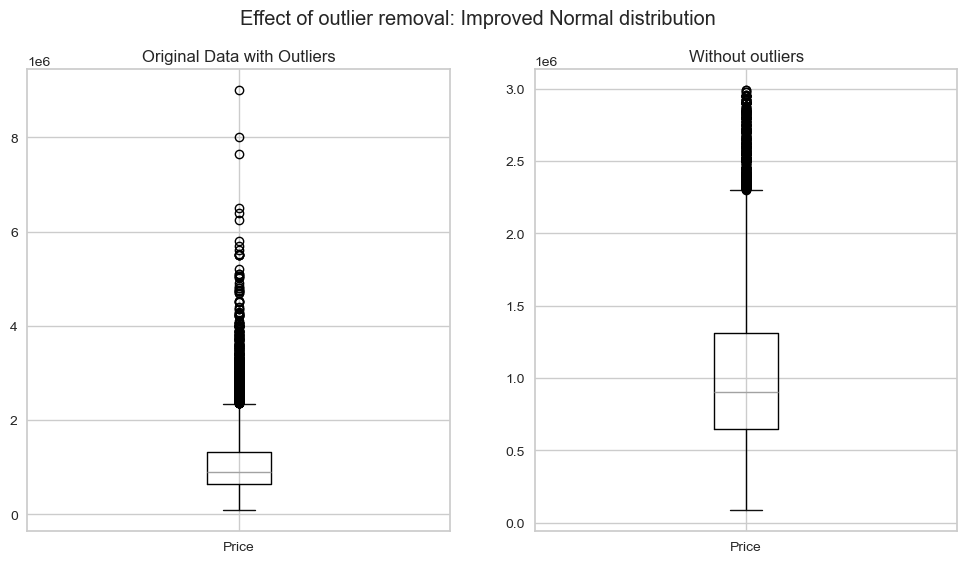

In [46]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Improved Normal distribution')

df_melb.boxplot(column=['Price'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['Price'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

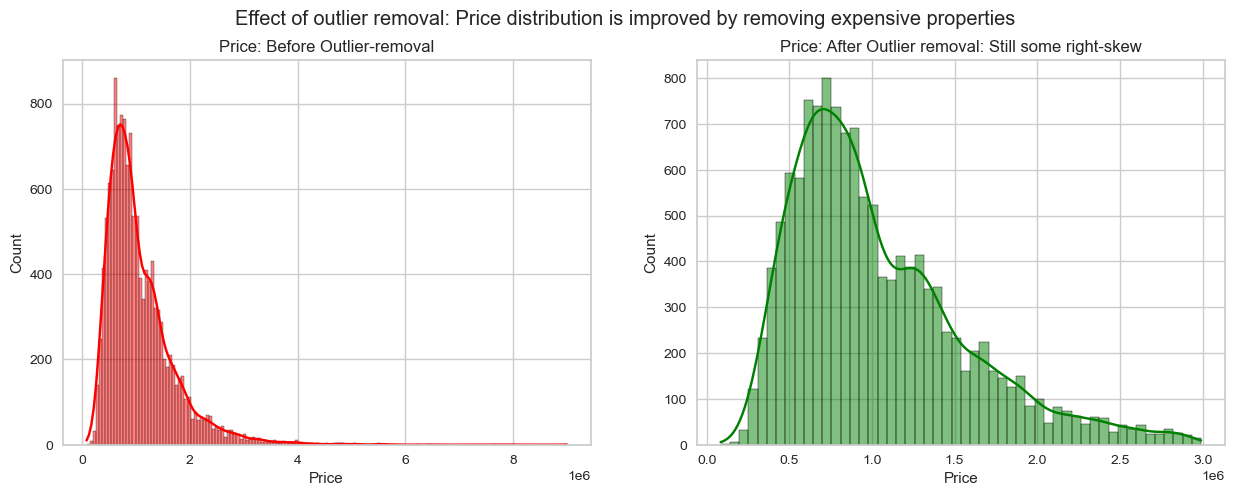

In [47]:
# Plots showing the effect of the outlier removal on the Price
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_melb['Price'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Price: Before Outlier-removal')

sns.histplot(df_melb_clean['Price'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Price: After Outlier removal: Still some right-skew')

fig.suptitle("Effect of outlier removal: Price distribution is improved by removing expensive properties")


plt.show()

### Landsize
Effect of the outlier removal

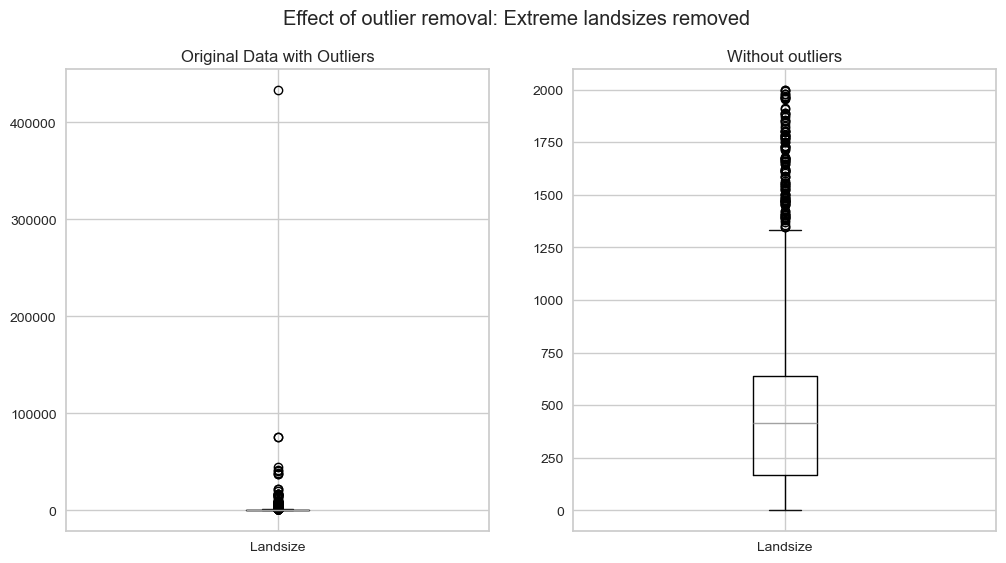

In [48]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme landsizes removed')

df_melb.boxplot(column=['Landsize'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['Landsize'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

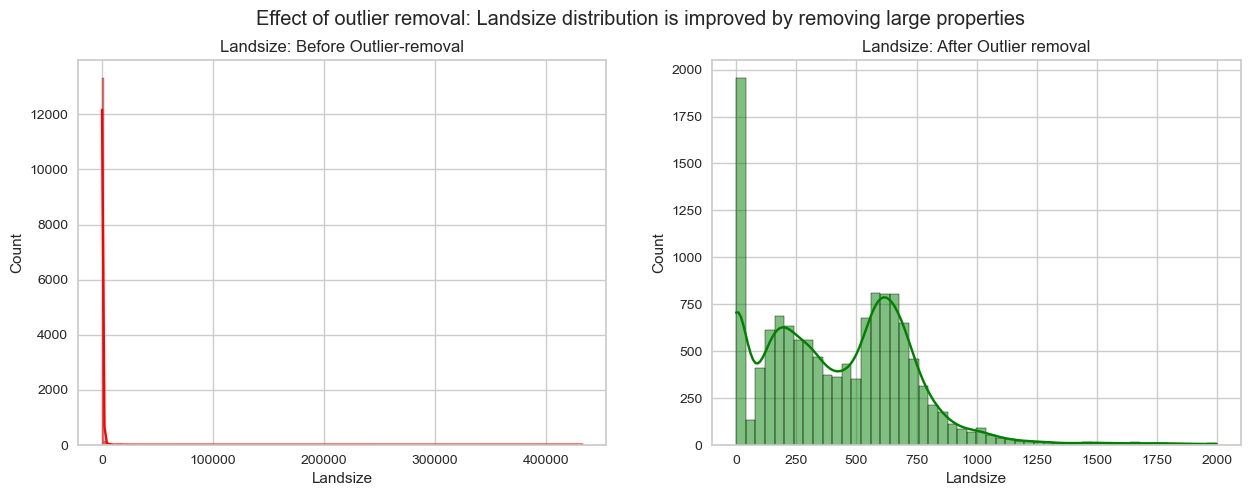

In [49]:
# Plots showing the effect of the outlier removal on the landsize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_melb['Landsize'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Landsize: Before Outlier-removal')

sns.histplot(df_melb_clean['Landsize'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Landsize: After Outlier removal')

fig.suptitle("Effect of outlier removal: Landsize distribution is improved by removing large properties")


plt.show()

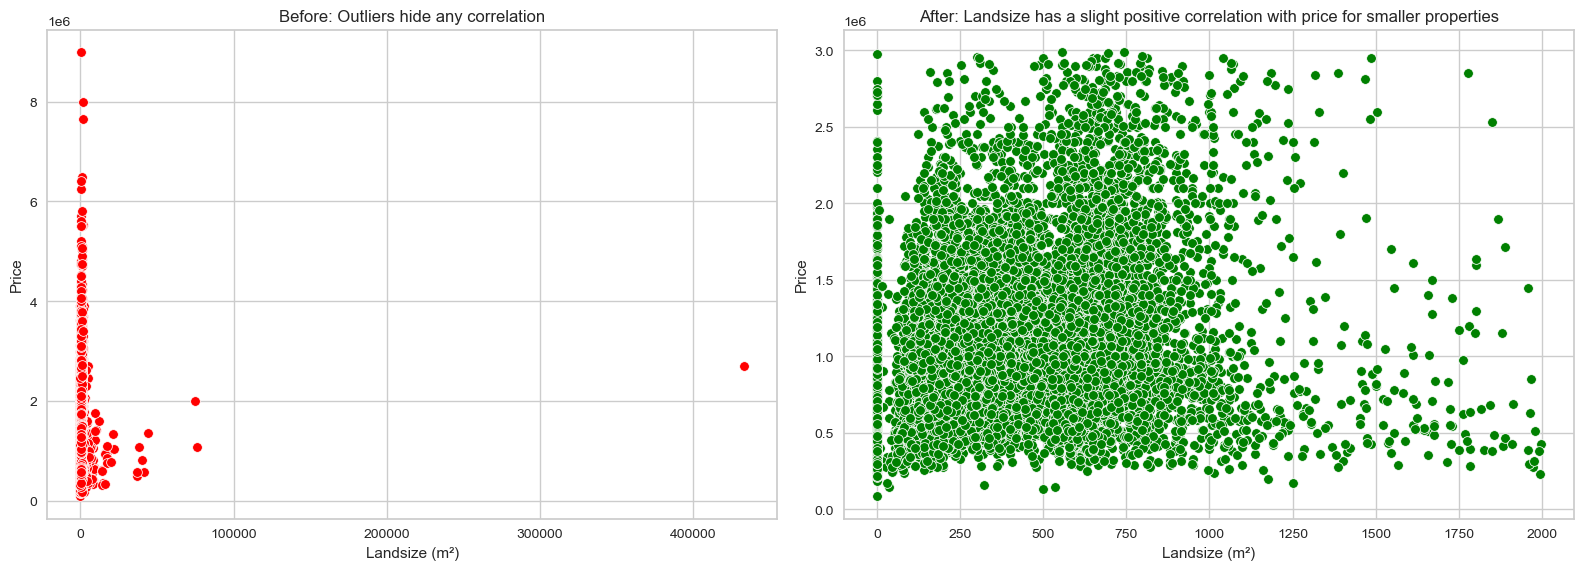

In [50]:
# Plot to see the correlation with price before and after cleaning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sns.scatterplot(data=df_melb, x='Landsize', y='Price', ax=ax1, color='red')
ax1.set_title('Before: Outliers hide any correlation')
ax1.set_xlabel('Landsize (m²)')
ax1.set_ylabel('Price')

# After outlier removal
sns.scatterplot(data=df_melb_clean, x='Landsize', y='Price', ax=ax2, color='green')
ax2.set_title('After: Landsize has a slight positive correlation with price for smaller properties')
ax2.set_xlabel('Landsize (m²)')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()

### BuildingArea
Effect of outlier removal

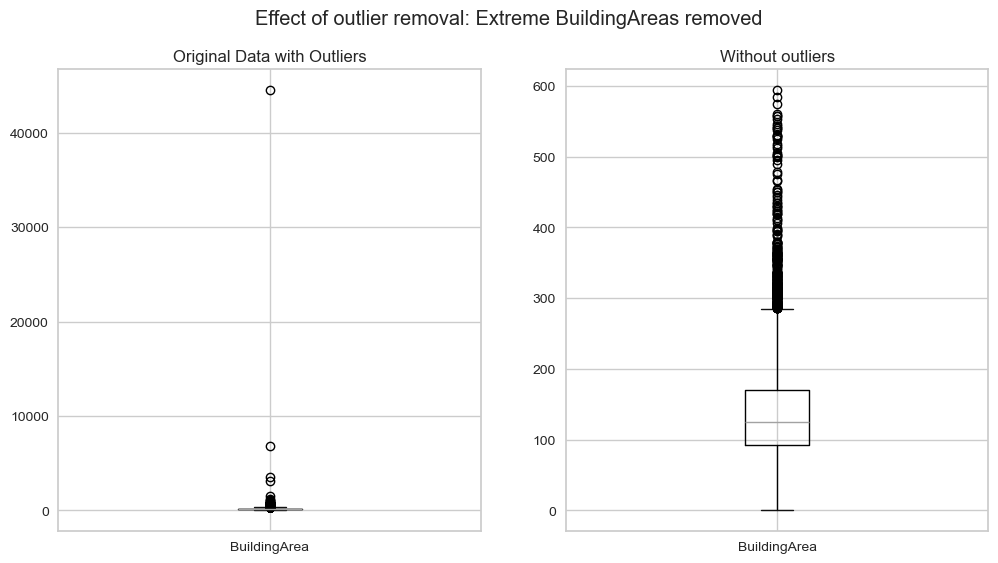

In [51]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme BuildingAreas removed')

df_melb.boxplot(column=['BuildingArea'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['BuildingArea'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

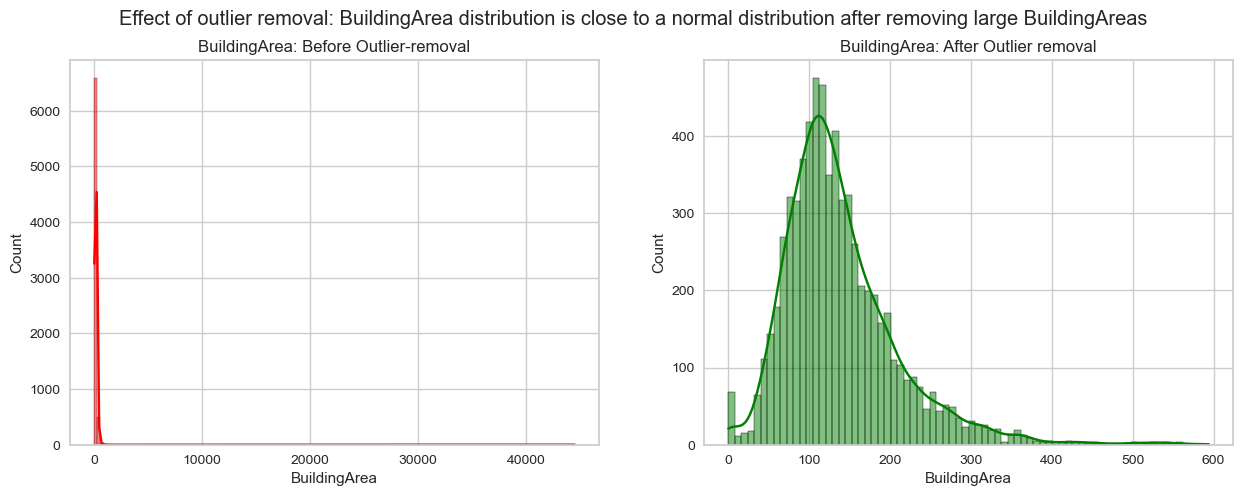

In [52]:
# Plots showing the effect of the outlier removal on the BuildingArea
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_melb['BuildingArea'], kde=True, ax=axes[0], color='red')
axes[0].set_title('BuildingArea: Before Outlier-removal')

sns.histplot(df_melb_clean['BuildingArea'], kde=True, ax=axes[1], color='green')
axes[1].set_title('BuildingArea: After Outlier removal')

fig.suptitle("Effect of outlier removal: BuildingArea distribution is close to a normal distribution after removing large BuildingAreas")


plt.show()

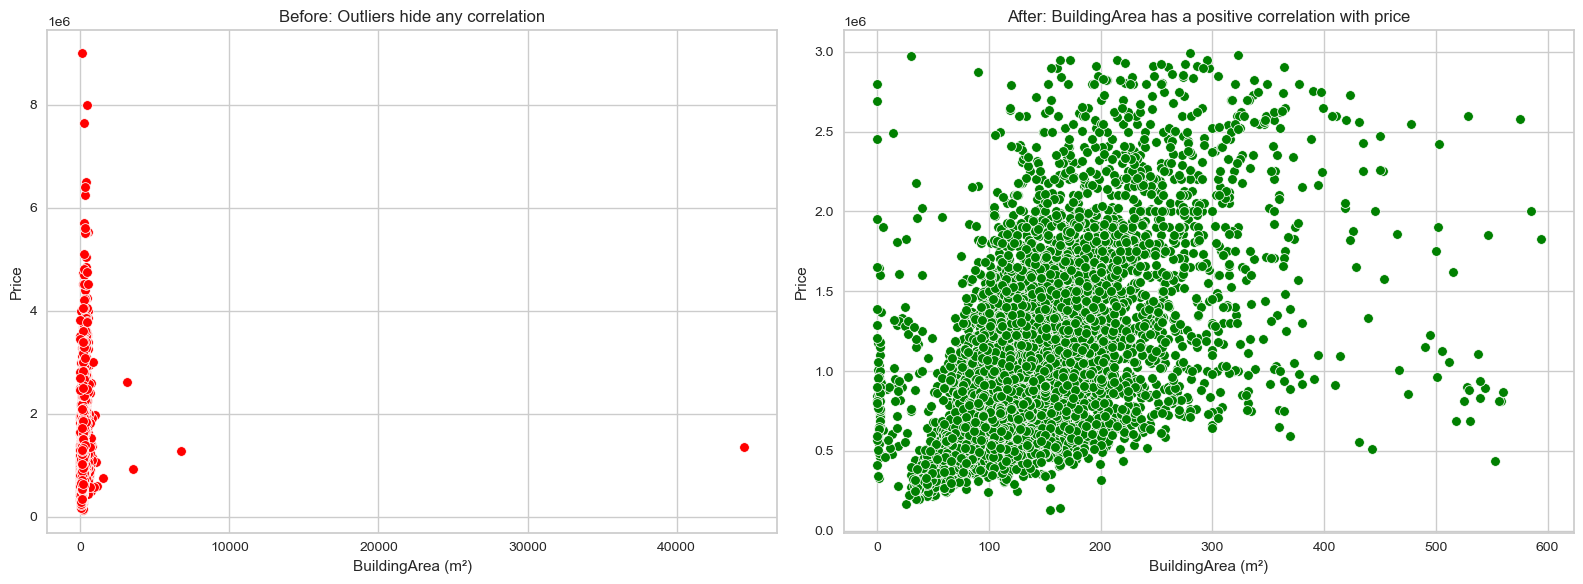

In [53]:
# Plot to see the correlation with price before and after cleaning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sns.scatterplot(data=df_melb, x='BuildingArea', y='Price', ax=ax1, color='red')
ax1.set_title('Before: Outliers hide any correlation')
ax1.set_xlabel('BuildingArea (m²)')
ax1.set_ylabel('Price')

# After outlier removal
sns.scatterplot(data=df_melb_clean, x='BuildingArea', y='Price', ax=ax2, color='green')
ax2.set_title('After: BuildingArea has a positive correlation with price')
ax2.set_xlabel('BuildingArea (m²)')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()

## 3.4 Fixing Missing and Odd Values

#### 'Landsize'
Some properties have a 'Landsize' of 0.

In [54]:
# We will check the properties where the land size is 0
landsize_0_count = df_melb_clean[df_melb_clean['Landsize'] == 0].groupby('Type').size()

print(landsize_0_count)

Type
h     169
t     138
u    1627
dtype: int64


We can see that it is mostly townhouses and units which has a landsize of 0, which makes sense given that the land is often not owned by the individual resident.

But for the 169 houses we will treat it as an error and calculate a new landsize for those:

In [55]:
# First we will find the houses and set the lansize to NaN, so we can replace it
houses = (df_melb_clean['Type'] == 'h') & (df_melb_clean['Landsize'] == 0)
df_melb_clean.loc[houses, 'Landsize'] = np.nan

# We will replace the NaN's with the median of similar houses in the same suburbs and a global median if there is still missing values
land_median = df_melb_clean[df_melb_clean['Type'] == 'h'].groupby('Suburb')['Landsize'].transform('median')

df_melb_clean['Landsize'] = df_melb_clean['Landsize'].fillna(land_median).fillna(df_melb_clean['Landsize'].median())

In [56]:
# We will check if there are still houses without a lansize of 0
landsize_0_count = df_melb_clean[df_melb_clean['Landsize'] == 0].groupby('Type').size()

print(landsize_0_count)

Type
t     138
u    1627
dtype: int64


We can see that it is now only townhouses and units with at landsize of 0 remaining

#### 'Bathroom'
Some properties have 0 'Bathrooms'

By law in Australia a residential property must have a bathroom, we will therefore treat bathroom == 0 as an error and replace it.

In [57]:
# First we will check how many are missing a bathroom
zero_bathrooms = df_melb_clean[df_melb_clean['Bathroom'] == 0]

# Given that it is only 34, it seems even more likely that it is an input error 
# and not at actual property with 0 Bathrooms
print(zero_bathrooms.shape)

(34, 20)


In [58]:
# 0 will be replaced with NaN
df_melb_clean.loc[df_melb_clean['Bathroom'] == 0, 'Bathroom'] = np.nan

# Calculate the median number of bathrooms by number of rooms
bathroom_median = df_melb_clean.groupby('Rooms')['Bathroom'].transform('median')

# Replace the NaN's
df_melb_clean['Bathroom'] = df_melb_clean['Bathroom'].fillna(bathroom_median)

# Check if there is still NaN's
print(df_melb_clean[df_melb_clean['Bathroom'] == 0].shape)

(0, 20)


#### 'Cars'
For the 62 missing car values we will use the median to fill the missing  as you can not have 1.4 car spaces

In [59]:
median_cars = df_melb_clean['Car'].median()
df_melb_clean['Car'] = df_melb_clean['Car'].fillna(median_cars)

#### 'BuildingArea'
Some properties have a 'BuildingArea' of 0

'BuildingArea' has 6450 missing values, which is a very important attribute of a property. We will therefore imputate the missing values.

In [60]:
# We will check the properties where the building area is 0, to see if they are development sites
m2_0_count = df_melb_clean[df_melb_clean['BuildingArea'] == 0].groupby('Type').size()

print(m2_0_count)

Type
h    13
t     3
dtype: int64


Since the properties with a BuildingArea of 0 are houses and townhouses and not development sites, we will treat them as an error:

In [61]:
# Find all properties with a building area smaller than 10 m2
small_properties = df_melb_clean['BuildingArea'] <= 10

# Replace the 0's with NaN's
df_melb_clean.loc[small_properties, 'BuildingArea'] = np.nan

In [62]:
# Check to see how the NaN's are distributed among the types of properties
df_melb_clean[df_melb_clean['BuildingArea'].isna()]['Type'].value_counts()

Type
h    4505
u    1351
t     449
Name: count, dtype: int64

So we can conclude that the rows with missing values are not just empty lots without houses.
Given that nearly half of the rows are missing the BuildingArea we will not drop it but fill it with the median for similar properties based on their type and number of rooms:

In [63]:
# Calculate the median for each group
grouped_median_m2 = df_melb_clean.groupby(['Type', 'Rooms'])['BuildingArea'].transform('median')

# Fill in the missing values, first with the grouped median and then with a global median if there are still missing values
df_melb_clean['BuildingArea'] = df_melb_clean['BuildingArea'].fillna(grouped_median_m2).fillna(df_melb_clean['BuildingArea'].median())

#### 'YearBuilt'

Earlier we found a house supposedly from 1196, so before we fill in the missing values for 'YearBuilt' we will investigate how many odd values we have in 'YearBuilt' and fix those

'YearBuilt' has 5375 missing values

In [64]:
old_houses = df_melb_clean[df_melb_clean['YearBuilt'] < 1800]

In [65]:
# We can see there only is one property from before 1800
# A quick search of the adress shows that it definitely is not from 1196 and therefore an error
old_houses.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
9968,Mount Waverley,5 Armstrong St,3,h,1200000.0,VB,McGrath,24/06/2017,14.2,3149.0,1.0,4.0,807.0,117.0,1196.0,Monash,-37.86788,145.12121,Eastern Metropolitan,13366.0


In [66]:
# We will replace the value of the odd house with NaN and then fill it in after
df_melb_clean.loc[9968, 'YearBuilt'] = np.nan

Now that 'YearBuilt' is clean from error we will replace the NaN's:

In [67]:
# We calculate the median build year for each suburb
grouped_median_year = df_melb_clean.groupby(['Suburb'])['YearBuilt'].transform('median')

# Fill in the missing values, first with the grouped median and then with th gloibal median if there is still missing values
df_melb_clean['YearBuilt'] = df_melb_clean['YearBuilt'].fillna(grouped_median_year).fillna(df_melb_clean['YearBuilt'].median())

#### 'CouncilArea'
'CouncilArea' has 1269 missing values

In [68]:
# We will see which suburbs are missing a CouncilArea to see if there is a pattern in some suburbs
missing_council = df_melb_clean[df_melb_clean['CouncilArea'].isna()]
missing_council['Suburb'].value_counts()

Suburb
Reservoir        36
Glen Iris        21
Sunbury          21
Balwyn North     19
Glen Waverley    19
                 ..
Keilor Park       1
Kings Park        1
Langwarrin        1
Monbulk           1
Tarneit           1
Name: count, Length: 260, dtype: int64

We can see that out of 314 Suburbs, 260 different Suburbs have a missing CouncilArea.

Our options:
* Map each suburb to a CouncilArea
* Replace the NaN's with the most common CouncilArea for each Suburb
* Find the nearest neighbour using KNeighborsClassifier
* Set to "unknown" CouncilArea
* Drop the column

By using KNeighborsClassifier we will calculate the nearest neighbour using lattitude and longtitude

In [69]:
# Separate rows with and without CouncilArea 
missing = df_melb_clean[df_melb_clean['CouncilArea'].isna()]
known = df_melb_clean[df_melb_clean['CouncilArea'].notna()]


# Use Lattitude and Longtitude as features to predict CouncilArea
X_known = known[['Lattitude', 'Longtitude']]
y_known = known['CouncilArea']

scaler_knn = StandardScaler()
X_known_scaled = scaler_knn.fit_transform(X_known)

X_train, X_val, y_train, y_val = train_test_split(
    X_known_scaled, y_known, test_size=0.2, random_state=42
)

# Find the optimal number of k
best_k, best_acc = None, 0
for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn.predict(X_val))
    print(f"k={k}, accuracy={acc:.3f}")
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"Best k: {best_k} with accuracy: {best_acc:.3f}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_known_scaled, y_known)

X_missing_scaled = scaler_knn.transform(missing[['Lattitude', 'Longtitude']])
df_melb_clean.loc[missing.index, 'CouncilArea'] = knn_final.predict(X_missing_scaled)

k=1, accuracy=0.982
k=2, accuracy=0.974
k=3, accuracy=0.978
k=4, accuracy=0.975
k=5, accuracy=0.974
k=6, accuracy=0.972
k=7, accuracy=0.973
k=8, accuracy=0.972
k=9, accuracy=0.971
k=10, accuracy=0.972
k=11, accuracy=0.971
k=12, accuracy=0.970
k=13, accuracy=0.968
k=14, accuracy=0.967
k=15, accuracy=0.969
Best k: 1 with accuracy: 0.982


#### Final Check

In [70]:
# Check to see if there are still missing values
df_melb_clean.isna().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [71]:
# Check to see if there is still odd values
df_melb_clean.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13083.000000,1.308300e+04,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000
mean,2.925934,1.032814e+06,10.215577,3104.535733,1.513185,1.599862,426.064014,134.405225,1964.201406,-37.808423,144.994617,7447.441871
std,0.938941,5.245125e+05,5.808215,90.640056,0.656863,0.950071,305.349079,60.041179,30.716504,0.079538,0.104380,4398.419190
min,1.000000,8.500000e+04,0.000000,3000.000000,1.000000,0.000000,0.000000,11.000000,1850.000000,-38.168020,144.431810,389.000000
25%,2.000000,6.500000e+05,6.300000,3044.000000,1.000000,1.000000,178.000000,96.000000,1950.000000,-37.856885,144.927500,4380.000000
50%,3.000000,9.000000e+05,9.400000,3083.000000,1.000000,2.000000,425.000000,129.000000,1970.000000,-37.800700,144.999870,6543.000000
75%,3.000000,1.310000e+06,13.000000,3148.000000,2.000000,2.000000,641.000000,161.000000,1980.500000,-37.754600,145.058550,10331.000000
max,10.000000,2.990000e+06,47.400000,3977.000000,8.000000,10.000000,1997.000000,594.000000,2018.000000,-37.408530,145.526350,21650.000000


## 3.5 Feature Engineering

In [72]:
# Calculate price per m2 for each row
df_melb_clean["Price_per_m2"] = df_melb_clean["Price"] / df_melb_clean["BuildingArea"]

In [73]:
# Calculate the age for each row
df_melb_clean["Age"] = 2026 - df_melb_clean["YearBuilt"]

In [74]:
# To improve our ML model we will combine the Victoria Regions which all have a low number of properties
df_melb_clean['Regionname'] = df_melb_clean['Regionname'].replace({
    'Northern Victoria': 'Victoria',
    'Eastern Victoria': 'Victoria',
    'Western Victoria': 'Victoria'
})

print(df_melb_clean['Regionname'].value_counts())

Regionname
Southern Metropolitan         4388
Northern Metropolitan         3784
Western Metropolitan          2910
Eastern Metropolitan          1443
South-Eastern Metropolitan     441
Victoria                       117
Name: count, dtype: int64


In [75]:
# Convert the Date from str to datetime
df_melb_clean['Date'] = pd.to_datetime(df_melb_clean['Date'], dayfirst=True)

In [105]:
# Extract day, month and year
df_melb_clean['Year'] = df_melb_clean['Date'].dt.year
df_melb_clean['Month'] = df_melb_clean['Date'].dt.month
df_melb_clean['Day'] = df_melb_clean['Date'].dt.day

print(df_melb_clean[['Date', 'Day', 'Month', 'Year']].head())

        Date  Day  Month  Year
0 2016-12-03    3     12  2016
1 2016-02-04    4      2  2016
2 2017-03-04    4      3  2017
3 2017-03-04    4      3  2017
4 2016-06-04    4      6  2016


## 3.6 Data Transformation

In [77]:
# Log transformation of the price
df_melb_clean['Log_Price'] = np.log(df_melb_clean['Price'])

In [78]:
# We will check the effects of the Log Transformation by looking at the skewness
print(f"Skewness of Price before Log Transformation: {df_melb_clean['Price'].skew():.2f}")
print(f"Skewness of Price after Log Transformation: {df_melb_clean['Log_Price'].skew():.2f}")

Skewness of Price before Log Transformation: 1.11
Skewness of Price after Log Transformation: -0.04


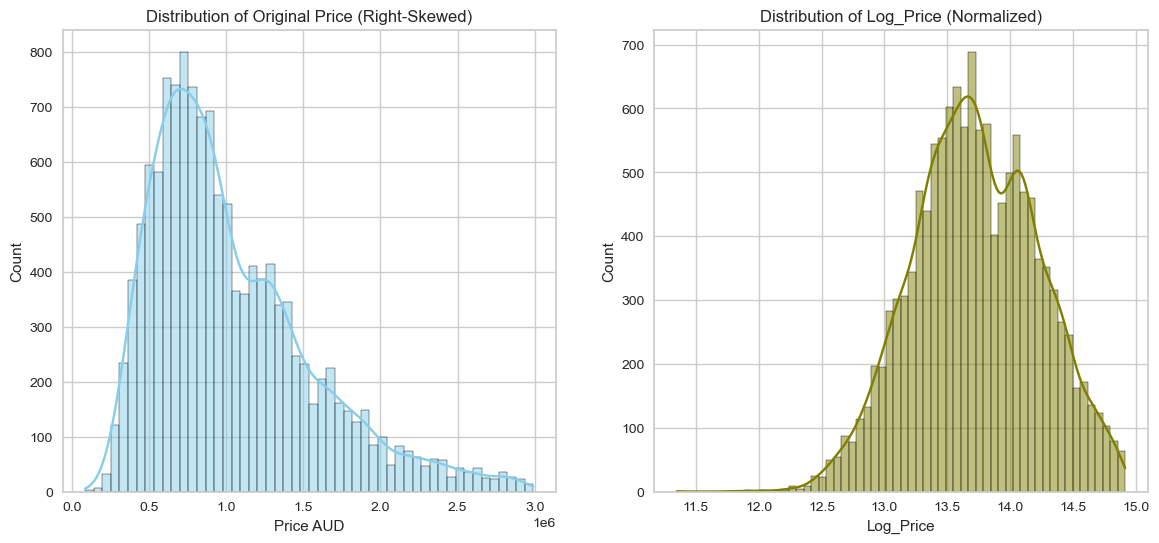

In [79]:
# Plot to see the effect of log transformation of the price
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Original Price
sns.histplot(df_melb_clean['Price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Original Price (Right-Skewed)')
axes[0].set_xlabel('Price AUD')

# Log_Price
sns.histplot(df_melb_clean['Log_Price'], kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribution of Log_Price (Normalized)')
axes[1].set_xlabel('Log_Price')


plt.show()

# 4. Data Exploration

## 4.1 EDA

#### Price_per_m2 visualized

In [113]:
# Uncomment "melbourne_map.add_child(colormap)" to see the map

melbourne_map = folium.Map(location=[-37.8136, 144.9631], zoom_start=10)

min_price = df_melb_clean['Price_per_m2'].min()
max_price = df_melb_clean['Price_per_m2'].quantile(0.95)

colormap = cm.LinearColormap(
    colors=['green', 'yellow', 'red'],
    vmin=min_price,
    vmax=max_price
)

for _, row in df_melb_clean.iterrows():
    folium.CircleMarker(
        location=[row['Lattitude'], row['Longtitude']],
        radius=4,
        color=colormap(row['Price_per_m2']),
        fill=True,
        fill_color=colormap(row['Price_per_m2']),
        fill_opacity=0.7
    ).add_to(melbourne_map)

colormap.caption = 'Price per m²'

# melbourne_map.add_child(colormap)


As seen on the map, the closer we get to the CBD or the ocean the higher the price per m2 is.

#### CouncilAreas visualized

In [112]:
# Uncomment "melbourne_map2" to see the map

councils = df_melb_clean['CouncilArea'].unique()

colors = [
    'red', 'blue', 'green', 'purple', 'orange',
    'darkred', 'lightred', 'beige', 'darkblue',
    'darkgreen', 'cadetblue', 'darkpurple', 'white',
    'pink', 'lightblue', 'lightgreen', 'gray', 'black'
]

color_map = {
    council: colors[i % len(colors)]
    for i, council in enumerate(councils)
}

melbourne_map2 = folium.Map(location=[-37.8136, 144.9631], zoom_start=10)

for _, row in df_melb_clean.iterrows():
    folium.CircleMarker(
        location=[row['Lattitude'], row['Longtitude']],
        radius=4,
        color=color_map[row['CouncilArea']],
        fill=True,
        fill_color=color_map[row['CouncilArea']],
        fill_opacity=0.7,
        popup=row['CouncilArea']
    ).add_to(melbourne_map2)

 # melbourne_map2



As seen on the map, using KNeighborsClassifier to imputate the missing values for CouncilArea has worked well and we can now easily identify where the CouncilAreas are.

### Categorical

#### Properties in each region

In [82]:
regions = df_melb_clean.groupby('Regionname').size()
regions

Regionname
Eastern Metropolitan          1443
Northern Metropolitan         3784
South-Eastern Metropolitan     441
Southern Metropolitan         4388
Victoria                       117
Western Metropolitan          2910
dtype: int64

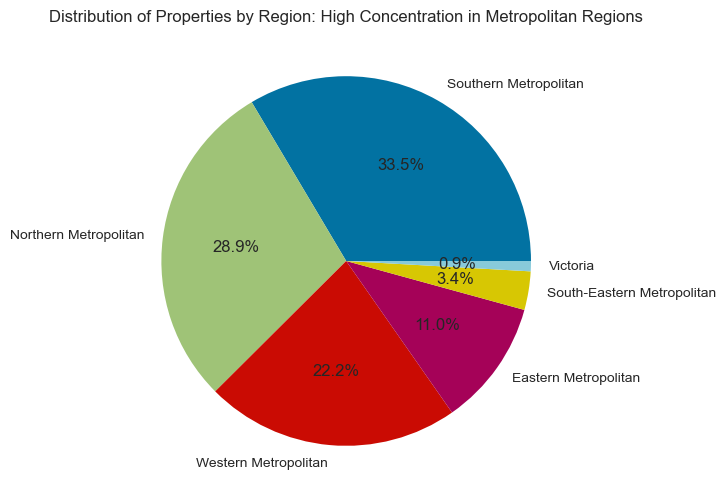

In [83]:
regions.sort_values(ascending=False).plot.pie(
    autopct='%1.1f%%', 
    figsize=(6, 6), 
    title='Distribution of Properties by Region: High Concentration in Metropolitan Regions'
)
plt.show()

#### Property distribution grouped by suburbs

In [84]:
suburbs = df_melb_clean.groupby('Suburb').size()
suburbs.sort_values(ascending=False)

Suburb
Reservoir             357
Bentleigh East        248
Preston               238
Richmond              236
Brunswick             219
                     ... 
Riddells Creek          1
Rockbank                1
Sandhurst               1
Beaconsfield Upper      1
Mount Evelyn            1
Length: 311, dtype: int64

<Axes: xlabel='Suburb'>

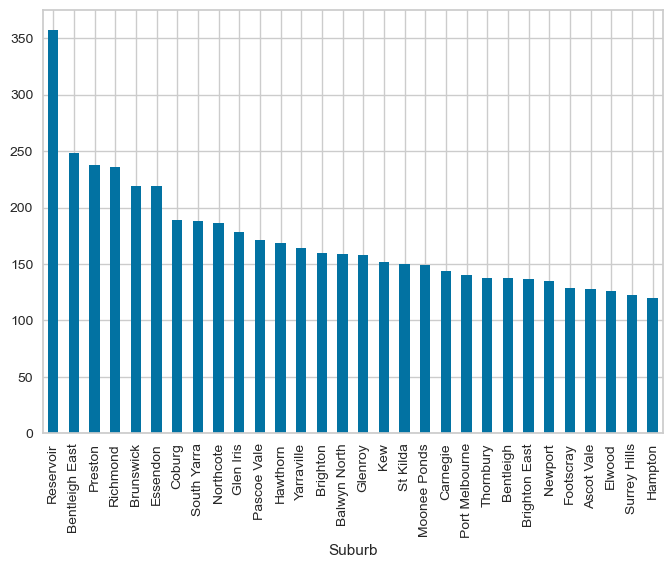

In [85]:
# The largest suburbs
suburbs.sort_values(ascending=False).head(30).plot.bar()

<Axes: xlabel='Suburb'>

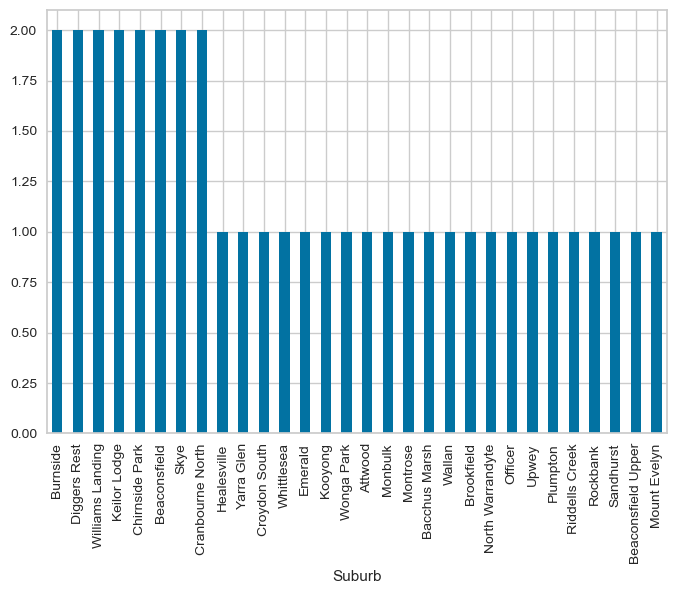

In [86]:
# The smallest suburbs
suburbs.sort_values(ascending=False).tail(30).plot.bar()

We can see that there is a very big difference in how many properties there is in each suburb. So to conclude if a specific suburb have a correlation with the price might be difficult, as one expensive sale in some suburbs will dictace a high mean for that whole suburb. To determine that, using CouncilArea would be better as there are more sales in each CouncilArea.

#### How does location affect housing prices across Melbourne?

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24512\4281254094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = mean_pr_region.values, y = mean_pr_region.index, palette='viridis')


Regionname
Southern Metropolitan         1.273101e+06
Eastern Metropolitan          1.091093e+06
South-Eastern Metropolitan    9.046161e+05
Northern Metropolitan         8.901522e+05
Western Metropolitan          8.652435e+05
Victoria                      5.672285e+05
Name: Price, dtype: float64


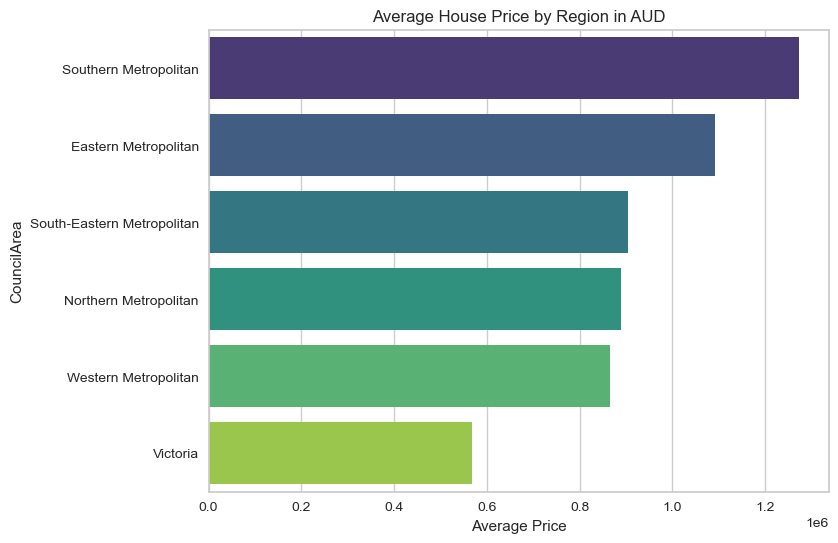

In [109]:
# Calculate the mean property price for each region
mean_pr_region = df_melb_clean.groupby('Regionname')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize = (8, 6))
sns.barplot(x = mean_pr_region.values, y = mean_pr_region.index, palette='viridis')

plt.title('Average House Price by Region in AUD')
plt.xlabel('Average Price')
plt.ylabel('CouncilArea')

print(mean_pr_region)

In [110]:
# Properties pr CouncilArea
councilAreas = df_melb_clean.groupby('CouncilArea').size()
councilAreas.sort_values(ascending=False)

CouncilArea
Moreland             1241
Boroondara           1139
Moonee Valley        1070
Darebin               999
Glen Eira             887
Maribyrnong           715
Stonnington           690
Banyule               632
Yarra                 631
Port Phillip          625
Bayside               511
Brimbank              472
Hobsons Bay           462
Melbourne             438
Monash                405
Whitehorse            373
Manningham            352
Kingston              278
Hume                  243
Whittlesea            225
Wyndham               120
Maroondah             110
Knox                  106
Melton                 85
Frankston              73
Greater Dandenong      65
Nillumbik              51
Casey                  46
Yarra Ranges           22
Cardinia                9
Macedon Ranges          6
Unavailable             1
Moorabool               1
dtype: int64

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24512\4196389624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = mean_pr_region.values, y = mean_pr_region.index, palette='viridis')


Text(0, 0.5, 'Region')

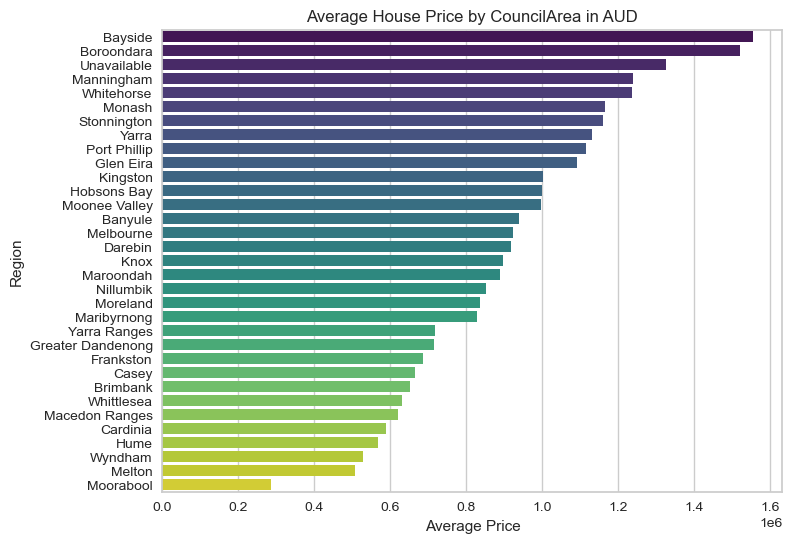

In [111]:
# Calculate the mean property price for each CouncilArea
mean_pr_region = df_melb_clean.groupby('CouncilArea')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize = (8, 6))
sns.barplot(x = mean_pr_region.values, y = mean_pr_region.index, palette='viridis')

plt.title('Average House Price by CouncilArea in AUD')
plt.xlabel('Average Price')
plt.ylabel('Region')

From the map above we can see that the CouncilArea (Bayside) with the highest mean is located by the ocean.

#### How do building prices differ between property types?

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24512\236292902.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x = 'Type', y = 'Price', data = df_melb_clean, palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24512\236292902.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x = 'Type', y = 'Log_Price', data = df_melb_clean, palette = 'viridis')


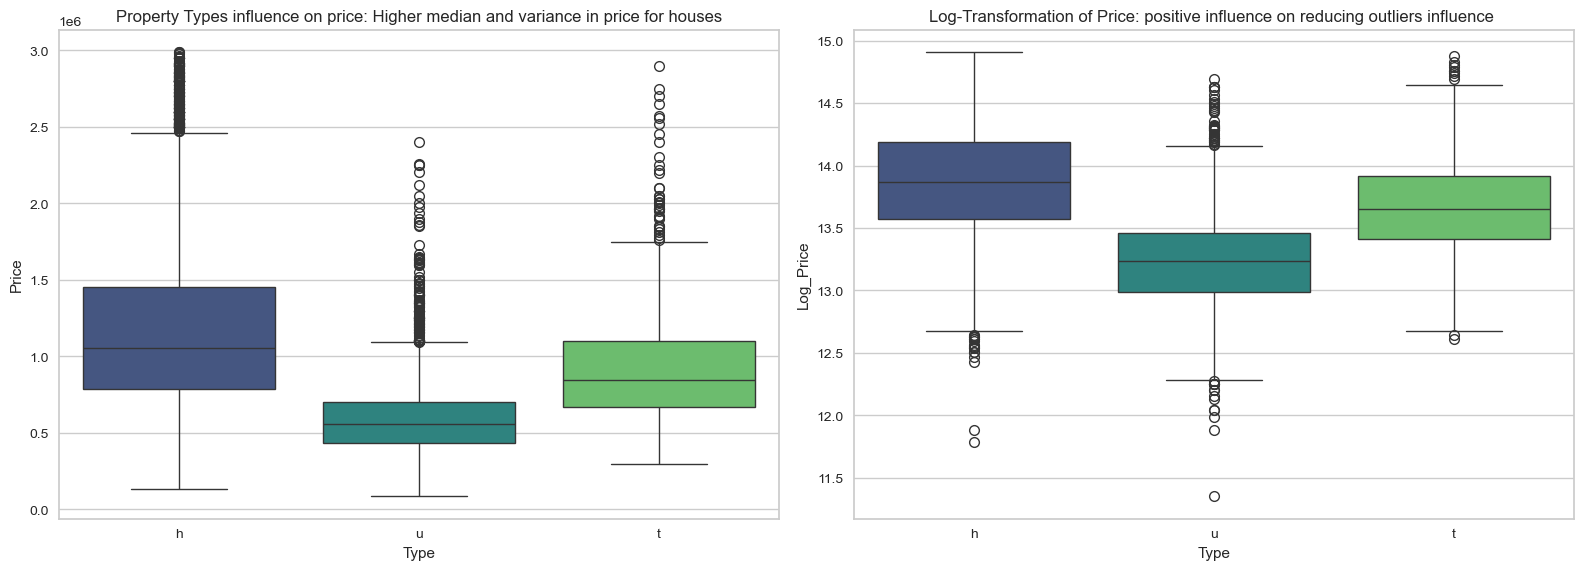

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Price
sns.boxplot(ax=axes[0], x = 'Type', y = 'Price', data = df_melb_clean, palette='viridis')
axes[0].set_title('Property Types influence on price: Higher median and variance in price for houses')
axes[0].set_ylabel('Price')

# Log_Price
sns.boxplot(ax=axes[1], x = 'Type', y = 'Log_Price', data = df_melb_clean, palette = 'viridis')
axes[1].set_title('Log-Transformation of Price: positive influence on reducing outliers influence ')
axes[1].set_ylabel('Log_Price')


plt.tight_layout()
plt.show()

* The plots shows higher prices, a higher median and a larger variance for the houses type, while there is very little variance in the units price, making the price more predictable for our ML model.
* We can also see that Log-transforming the prices reduces the influence of outliers and normalises the price distribution

### Numerical

#### Price correlation with distance from CBD (Central Bussines District):

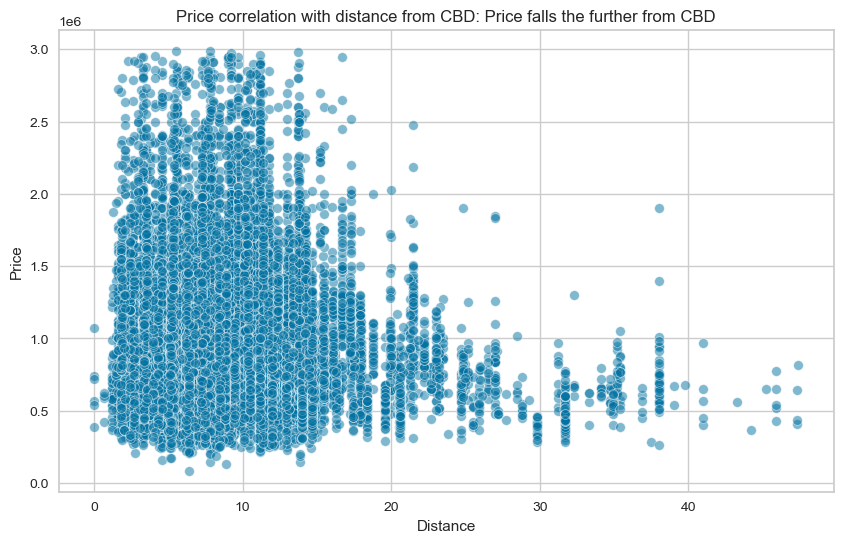

In [90]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = df_melb_clean, x='Distance', y='Price', alpha=0.5)
plt.title('Price correlation with distance from CBD: Price falls the further from CBD')
plt.show()

#### How does the age affect the price?

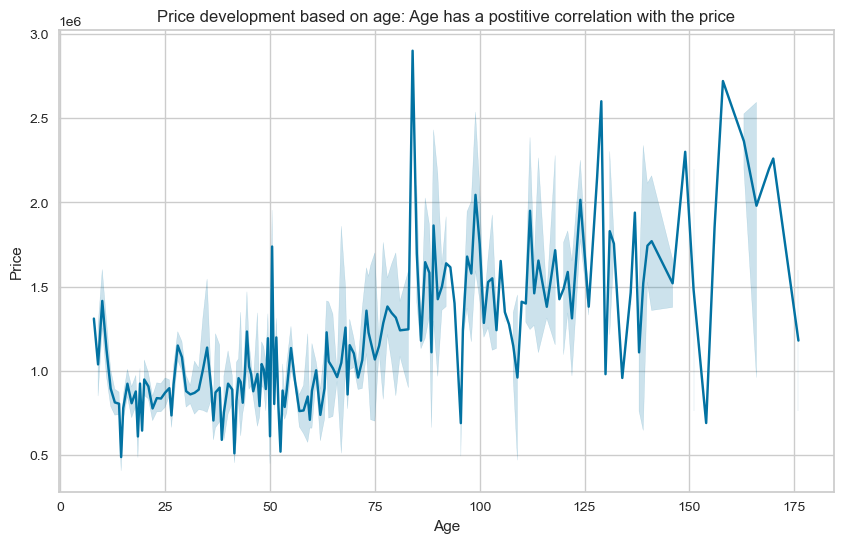

In [91]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = df_melb_clean, x='Age', y='Price')
plt.title('Price development based on age: Age has a postitive correlation with the price')
plt.show()

The higher the age the bigger the swings in price. A high price for an old building could be because it might be in the older, often more popular areas of the town. And a high age and low price could simply be a detoriated building

#### Rooms Distribution
We visualise the distribution of the number of rooms to understand 
the most common property sizes in Melbourne.

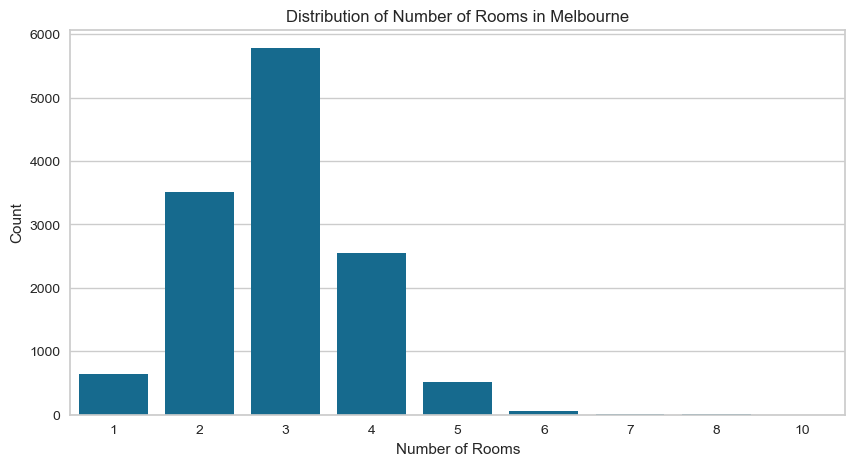

In [94]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Rooms', data=df_melb_clean)
plt.title('Distribution of Number of Rooms in Melbourne')
plt.xlabel('Number of Rooms')
plt.ylabel('Count')
plt.show()

## 4.2 Correlations

In [95]:
# Person correlation for numeric values:
corr = df_melb_clean.corr(method='pearson', numeric_only=True)

In [96]:
corr

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,Price_per_m2,Age,Year,Month,Day,Log_Price
Rooms,1.000000,0.495985,0.302882,0.046529,0.582926,0.397197,0.444305,0.774326,0.004176,0.024205,0.091732,-0.081739,-0.119196,-0.004176,0.102292,0.026150,0.010718,0.538692
Price,0.495985,1.000000,-0.172141,0.104988,0.419471,0.212694,0.289616,0.528585,-0.308378,-0.227335,0.220044,-0.055353,0.478234,0.308378,0.014250,0.018112,-0.009661,0.955474
Distance,0.302882,-0.172141,1.000000,0.429569,0.144221,0.268439,0.384826,0.233044,0.300584,-0.137298,0.247342,-0.047935,-0.316462,-0.300584,0.258611,0.025340,0.014918,-0.157139
Postcode,0.046529,0.104988,0.429569,1.000000,0.111010,0.040754,0.068164,0.060310,0.064654,-0.410002,0.450874,0.063814,0.066355,-0.064654,0.100487,0.019489,-0.002654,0.083376
Bathroom,0.582926,0.419471,0.144221,0.111010,1.000000,0.300038,0.184762,0.600301,0.161733,-0.063699,0.113801,-0.055446,-0.038554,-0.161733,0.046164,0.023614,-0.011870,0.413775
Car,0.397197,0.212694,0.268439,0.040754,0.300038,1.000000,0.355794,0.361009,0.130747,0.004951,0.056566,-0.026071,-0.065020,-0.130747,0.092270,0.027240,0.004657,0.231154
Landsize,0.444305,0.289616,0.384826,0.068164,0.184762,0.355794,1.000000,0.390165,-0.009410,0.036502,0.146675,-0.060674,-0.030388,0.009410,0.156669,0.014060,0.000439,0.304041
BuildingArea,0.774326,0.528585,0.233044,0.060310,0.600301,0.361009,0.390165,1.000000,0.052954,-0.004972,0.101157,-0.071441,-0.243829,-0.052954,0.057909,0.034595,0.000618,0.542401
YearBuilt,0.004176,-0.308378,0.300584,0.064654,0.161733,0.130747,-0.009410,0.052954,1.000000,0.044662,0.004065,0.012783,-0.296139,-1.000000,0.102185,-0.002791,-0.004227,-0.314462
Lattitude,0.024205,-0.227335,-0.137298,-0.410002,-0.063699,0.004951,0.036502,-0.004972,0.044662,1.000000,-0.355067,0.053483,-0.190629,-0.044662,-0.002303,-0.001941,0.003173,-0.223679


Heatmap of the most important and interesting attributes:

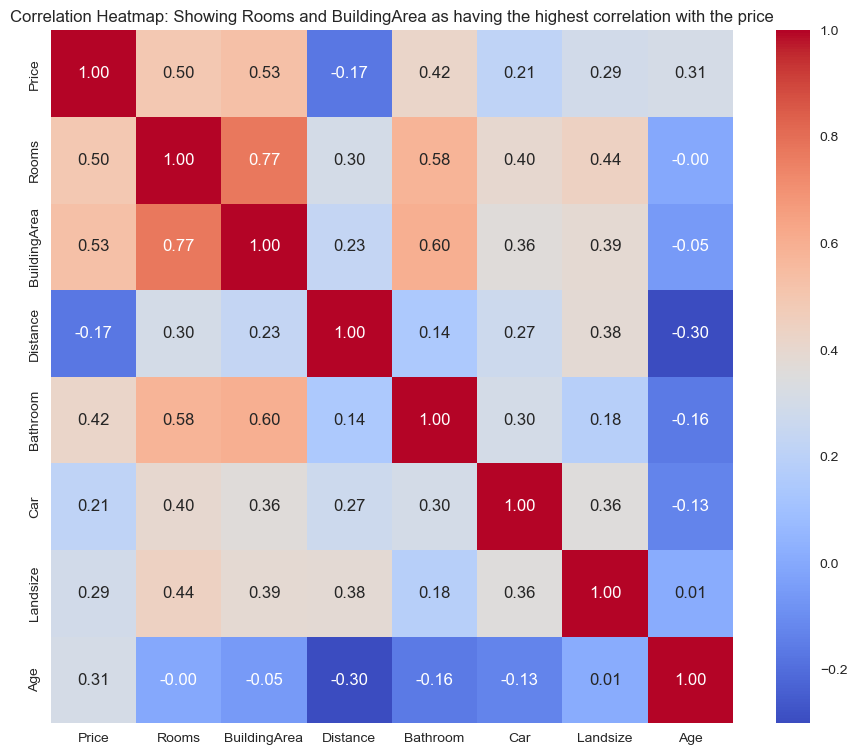

In [97]:
columns = ['Price', 'Rooms', 'BuildingArea', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Age']
corr_subset = df_melb_clean[columns].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Showing Rooms and BuildingArea as having the highest correlation with the price')
plt.show()

Scatter plot to visualize some of the positive and negative correlations aswell as some discrete values:

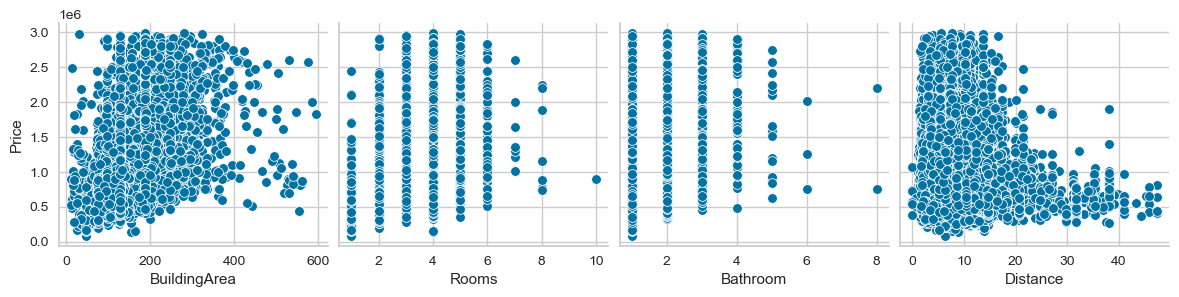

In [98]:
sns.pairplot(df_melb_clean, x_vars=['BuildingArea', 'Rooms', 'Bathroom', 'Distance'], y_vars='Price', height=3)

#### Correlation Findings
* Rooms, BuildingArea and Bathroom all have large postive correlations with the price
* Distance from CBD (Central Bussiness District) shows that the further a property is from the CBD, the more negatively the price is influenced
* A high Age does interestingly enough have a positive impact on the price. This could be that the older buildings are in the more attractive parts of town and/or newer builds are further from the CBD and most likely units and townhouses.
* Multicollinearity: High correlation (0.76) between 'Rooms' and 'BuildingArea'. 

## 4.3 Inferential Statistics

### Testing Hypotheses 1: price/m2 in houses vs units

$H_A$: The average price/m2 is significantly higher for houses than for units.

$H_0$: There is no significant difference in the price/m2 for houses and units

($\alpha$) Significance level: 0,05 (5%)

In [99]:
# First we will divide the DF by type
houses_m2_price = df_melb_clean[df_melb_clean['Type'] == 'h']['Price_per_m2']
units_m2_price = df_melb_clean[df_melb_clean['Type'] == 'u']['Price_per_m2']

In [100]:
houses_m2_price.describe()

count      9145.000000
mean       8391.091891
std        4830.027196
min         786.618445
25%        5589.147287
50%        7620.155039
75%       10209.302326
max      177857.142857
Name: Price_per_m2, dtype: float64

In [101]:
units_m2_price.describe()

count     2839.000000
mean      7842.228786
std       2970.008537
min       1770.833333
25%       6276.088929
50%       7528.384279
75%       8899.509804
max      88000.000000
Name: Price_per_m2, dtype: float64

In [102]:
# t-test and p-value
t_stat, p_val = stats.ttest_ind(houses_m2_price, units_m2_price)

print(f"t-value: {t_stat:.2f}")
print(f"p-value: {p_val:.11f}")

* t-value: Given our significance level is 5%, then a value larger than 1.96 is very significant
* p-value: The extremely low p-value (p-value < 0,05) indicates that the chance that our findings are a coincidence is extremely low
* Conclusion: We will therefore reject the $H_0$ and accept the $H_A$

#### Calculate the confidencesinterval for 'Type' houses

##### Standard Error
The uncertainty of the mean of the 'Price_Pr_m2'

$$SE = \frac{std}{\sqrt{count}}= \frac{4906}{\sqrt{9259}} = \frac{4906}{96.22} \approx \mathbf{51 \text{ AUD}}$$

##### Margin Of Error
Margin of error is calculated by our predetermined significance level

Significance level ($\alpha$): 0,05 (5%) = 1,96 Z

Significance level ($\alpha$): 0,01 (1%) = 2,58 Z

$$ME = Z \cdot SE = 1.96 \cdot 50.99 \approx \mathbf{100 \text{ AUD}}$$

##### Confidence Interval
The interval we with 95% certainty can say the real mean is in between

$$CI = \text{Mean} \pm \text{Margin of Error}$$

Lower bound: $ 8448 - 100 = \mathbf{8348 \text{ AUD.}}$

Upper bound: $8448 + 100 = \mathbf{8548 \text{ AUD.}}$

#### Calculating the confidencesinterval for 'Type' units

##### Standard Error
The uncertainty of the mean of the 'Price_Pr_m2'

$$SE = \frac{std}{\sqrt{count}}= \frac{2970}{\sqrt{ 2839}} = \frac{2970}{53.28} \approx \mathbf{56 \text{ AUD}}$$

##### Margin Of Error
Margin of error is calculated by our predetermined significance level

Significance level ($\alpha$): 0,05 (5%) = 1,96 Z

Significance level ($\alpha$): 0,01 (1%) = 2,58 Z

$$ME = Z \cdot SE = 1.96 \cdot 56 \approx \mathbf{110 \text{ AUD}}$$

##### Confidence Interval
The interval we with 95% certainty can say the real mean is in between

$$CI = \text{Mean} \pm \text{Margin of Error}$$

Lower bound: $7842 - 110 = \mathbf{7732 \text{ AUD.}}$

Upper bound: $7842 + 110 = \mathbf{7952 \text{ AUD.}}$

#### Conclusion to confidence intervals
Houses: $[8348 - 8548] \text{ AUD}$

Units: $[7732 - 7952] \text{ AUD}$

Given that there is no overlap in the 2 confidence intervals, then we can with a high statistical certainty say that houses on average have a higher price/m2 than units

### Testing Hypotheses 2: 

In [103]:
contingency_table = pd.crosstab(df_melb_clean['Type'], df_melb_clean['Regionname'])
print(contingency_table)

# Chi-squared test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_val:.10f}")

Regionname  Eastern Metropolitan  Northern Metropolitan  \
Type                                                      
h                           1152                   2725   
t                            117                    299   
u                            174                    760   

Regionname  South-Eastern Metropolitan  Southern Metropolitan  Victoria  \
Type                                                                      
h                                  381                   2501       114   
t                                   25                    421         0   
u                                   35                   1466         3   

Regionname  Western Metropolitan  
Type                              
h                           2272  
t                            237  
u                            401  
Chi-squared statistic: 693.66
Degrees of freedom: 10
P-value: 0.0000000000


In [104]:
monthlygroups = [group['Price'].values for group in df_melb_clean.groupby('Month')]

f_stat, p_value = stats.f_oneway(*monthly_groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.6f}")

TypeError: tuple indices must be integers or slices, not str

# 5. Data Modelling

## 5.1 Clustering ML Model

In [ ]:
scaler_cluster = StandardScaler()

# Choosen features for clustering based on their correlation with the price
# Price has not been included as we will use the result for our Linear Regression Model to predict the price
features_cluster = ['Rooms', 'Distance', 'Bathroom', 'BuildingArea', 'Type', 'Age']

# Encoding
X_cluster = pd.get_dummies(df_melb_clean[features_cluster], drop_first=True)

# Splitting data
X_train_c, X_test_c = train_test_split(X_cluster, test_size=0.2, random_state=123)

# Scaling data
X_train_c_scaled_df = pd.DataFrame(scaler_cluster.fit_transform(X_train_c), columns=X_train_c.columns,index=X_train_c.index)
X_test_c_scaled_df = pd.DataFrame(scaler_cluster.transform(X_test_c), columns=X_test_c.columns, index=X_test_c.index)

### Choosing the number of clusters

#### Elbow Method

In [ ]:
# Elbow method to determine optimal number of clusters
K = range(2, 10)
distortions = []

for k in K:
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X_train_c_scaled_df)
    dist = sum(np.min(cdist(X_train_c_scaled_df, model.cluster_centers_, 'euclidean'), axis=1)) / X_train_c_scaled_df.shape[0]
    distortions.append(dist)

print("Distortion: ", distortions)

In [ ]:
# Plot the distortion to discover the elbow to determine the optimal number of clusters
plt.title('Elbow Method for Optimal K')
plt.plot(K, distortions, 'bx-')
plt.xlabel('K')
plt.ylabel('Distortion')
plt.show()

The Elbow methods suggest using 4 clusters

#### Sillhouette Score

In [ ]:
# Determine k by maximising the silhouette score for each number of clusters
scores = []
K = range(2,10)
for k in K:
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X_train_c_scaled_df)
    score = metrics.silhouette_score(X_train_c_scaled_df, model.labels_, metric='euclidean', sample_size=len(X_train_c_scaled_df))
    print("\nNumber of clusters =", k, "\tSilhouette score =", score)
    scores.append(score)

In [ ]:
plt.title('Silhouette Score Method for Discovering the Optimal K')
plt.plot(K, scores, 'bx-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

The silhouette method suggest using 4 clusters

### Making the Clustering Model

In [ ]:
# Optimal number of clusters
num_clusters = 4

# KInstance of KMeans classifier
kmeans = KMeans(init = 'k-means++', n_clusters=num_clusters, n_init=20)

# Train the KMeans clustering model
kmeans.fit(X_train_c_scaled_df)

### Using the Model on our Data set

In [ ]:
# Scale the entire dataset
X_all_c_scaled = pd.DataFrame(
    scaler_cluster.transform(X_cluster),
    columns=X_cluster.columns,
    index=X_cluster.index
)

# Predict clusters for the entire dataset
df_melb_clean['Cluster'] = kmeans.predict(X_all_c_scaled)

### Exploring the different clusters

In [ ]:
# Predict the clusters in X
predicted = kmeans.predict(X_train_c_scaled_df)
predicted

In [ ]:
centers = kmeans.cluster_centers_
centers

In [ ]:
centers = kmeans.cluster_centers_

dist_idx = X_train_c_scaled_df.columns.get_loc('Distance')
area_idx = X_train_c_scaled_df.columns.get_loc('BuildingArea')

plt.scatter(X_train_c_scaled_df.iloc[:, dist_idx], X_train_c_scaled_df.iloc[:, area_idx],
            c=kmeans.labels_, s=50, cmap='viridis')
plt.scatter(centers[:, dist_idx], centers[:, area_idx], s=200, linewidths=2,
            color='blue', marker='*', zorder=3, facecolors='black')
plt.xlabel('Distance')
plt.ylabel('BuildingArea')
plt.title('Clusters: Distance vs BuildingArea')
plt.grid(True)
plt.show()

In [ ]:
centers_original = pd.DataFrame(
    scaler_cluster.inverse_transform(kmeans.cluster_centers_),
    columns=X_train_c.columns
)

plt.scatter(X_train_c['Distance'], 
            df_melb_clean.loc[X_train_c.index, 'Price'],
            c=kmeans.labels_, s=50, cmap='viridis')
plt.scatter(centers_original['Distance'], 
            df_melb_clean.loc[X_train_c.index, 'Price'].groupby(kmeans.labels_).mean(),
            s=200, marker='*', color='black', zorder=3)
plt.xlabel('Distance')
plt.ylabel('Price')
plt.title('Clusters: Distance vs Price')
plt.grid(True)
plt.show()

#### Checking the different clusters means

In [ ]:
# Add cluster labels to training data for profiling
analysis_df = X_train_c.copy()
analysis_df['Price'] = df_melb_clean.loc[X_train_c.index, 'Price']
analysis_df['Cluster'] = kmeans.labels_

# Calculate mean for each cluster
cluster_profile = analysis_df.groupby('Cluster').mean()

# Count number of properties in each cluster
cluster_profile['Count'] = analysis_df.groupby('Cluster').size()

print(cluster_profile[['Price', 'Distance', 'BuildingArea', 'Rooms', 'Count']].round(2))

### Validating the Model

In [ ]:
score = silhouette_score(X_train_c_scaled_df, kmeans.labels_, metric='euclidean')
print('Silhouette Score: %.3f' % score)

In [ ]:
# Visualize the silhouette scores of all points
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
visualizer.fit(X_train_c_scaled_df)
visualizer.show()

### Using the Model On New Unknow Data

In [ ]:
# Define a new unknown property
new_property = pd.DataFrame([{
    'Rooms': 3,
    'Distance': 10,
    'Bathroom': 2,
    'BuildingArea': 120,
    'Age': 20,
    'Type': 'h'
    
}])

# Encode
new_property_encoded = pd.get_dummies(new_property, drop_first=True)

# Add the new encoded columns
new_property_encoded = new_property_encoded.reindex(
    columns=X_train_c.columns, fill_value=0
)

# Scale
new_property_scaled = scaler_cluster.transform(new_property_encoded)

# Predict cluster
cluster = kmeans.predict(new_property_scaled)
print(f"Property belongs to cluster: {cluster[0]}")

### Conclusion

The K-Means clustering model identified 4 clusters using the features
'Rooms', 'Distance', 'Bathroom', 'BuildingArea', 'Age' and 'Type', with a silhouette score of 0.348 

The silhouette scores indicates that the clusters are not too clearly seperated. But this can also be expected given that property data naturally 
overlaps without clear distinct boundaries.

### Saving the Model

In [ ]:
# filename = 'kmmodel_melb.pkl'
# joblib.dump(kmeans, filename)

## 5.2 Linear Regression Model

In [ ]:
scaler_reg = StandardScaler()

# Non-dependent variables
features_reg = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Type', 'Age', 'Cluster', 'CouncilArea']

# Dependent variabel
y = df_melb_clean['Log_Price']

# Encoding
X_reg = pd.get_dummies(df_melb_clean[features_reg], 
                       columns=['Type', 'Cluster', 'CouncilArea'], 
                       drop_first=True)

# Splitting the data
X_train_reg, X_test_reg, y_train, y_test = train_test_split(X_reg, y, test_size=0.2, random_state=123)

# Scaling 
X_train_reg_scaled_df = pd.DataFrame(scaler_reg.fit_transform(X_train_reg), columns=X_train_reg.columns, index=X_train_reg.index)
X_test_reg_scaled_df = pd.DataFrame(scaler_reg.transform(X_test_reg), columns=X_test_reg.columns, index=X_test_reg.index)

### Evaluating the scaling and encoding

In [ ]:
# Check the encoding and scaling
X_train_reg_scaled_df.head()

In [ ]:
# Check the Min and Max values
print(X_train_reg_scaled_df.max())
print(X_train_reg_scaled_df.min())

In [ ]:
# Some values are many std's from the mean so we will clip it from -3 to 3
X_train_reg_scaled_df = X_train_reg_scaled_df.clip(lower=-3, upper=3)
X_test_reg_scaled_df = X_test_reg_scaled_df.clip(lower=-3, upper=3)

In [ ]:
# Check the scaled values again
print(X_train_reg_scaled_df.max())
print(X_train_reg_scaled_df.min())

### Making the Model

In [ ]:
# Create an instance of a linear Regression model
myreg = LinearRegression()

In [ ]:
# Fit it to the data
myreg.fit(X_train_reg_scaled_df, y_train)
myreg

In [ ]:
# Print the calculated coefficients
a = myreg.coef_
b = myreg.intercept_

coefficients_df = pd.DataFrame(a, X_train_reg_scaled_df.columns, columns=['Coefficient'])
print(coefficients_df.sort_values(by='Coefficient', ascending=False))

* We can see that adding 1 std room adds 9.9% to the price
* Adding 1 standard deviation to Bathroom increases the price by 7.3%
* Adding 1 std to the BuildingArea adds 9% to the price
* Adding 1 std to the distance reduces the price with 22.4%
* Units reduces the price with 24.5% compared to houses
* Cluster_1 increaces the price with 12.6% compared to cluser_0

##### How much does the price increase when adding a bathroom?

In [ ]:
df_melb_clean['Bathroom'].std()

Adding 1 standard deviation (≈ 0.65 bathrooms) to Bathroom increases 
  the price by 7% — roughly equivalent to adding 1 extra bathroom 
  increases the price by approximately 11%

In [ ]:
# Plot to how the features affect the price
# The reference region is 'Eastern Metropolitan'
coefficients_df.sort_values(by='Coefficient').plot(kind='barh', figsize=(8, 6))
plt.title('How the features affect the price per std')
plt.xlabel('Effect on Price')
plt.show()

In [ ]:
# Plot to how the features affect the price without the council areas
coefficients_filtered = coefficients_df[~coefficients_df.index.str.startswith('CouncilArea')]

coefficients_filtered.sort_values(by='Coefficient').plot(kind='barh', figsize=(8, 6))
plt.title('How the features affect the price per std')
plt.xlabel('Effect on Price')
plt.show()

### Testing the Model

In [ ]:
# Calculate predictions on the testing set
y_predicted_log = myreg.predict(X_test_reg_scaled_df)

# Convert back to AUD from Log-transformed price
y_predicted = np.exp(y_predicted_log)
y_test_actual = np.exp(y_test)


print(y_predicted)

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_predicted, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         color='red')
plt.xlabel('Actual Price (AUD)')
plt.ylabel('Predicted Price (AUD)')
plt.title('Predicted vs Actual Price: Model shows a tendency to undervalue expensive properties')
plt.show()

#### Test of the Model with the known values of a house

In [ ]:
results = pd.DataFrame({
    'Actual': y_test_actual.iloc[:10].values,
    'Predicted': np.exp(myreg.predict(X_test_reg_scaled_df.iloc[:10])),
})

print(results)

### Evaluating the Model

#### MAE
Mean Absolute Error (MAE) is the mean of the absolute value of the errors:

In [ ]:
mae = metrics.mean_absolute_error(y_test_actual, y_predicted)
print(mae)

#### MSE and RMSE
Mean Squared Error (MSE) is the mean of the squared errors:

In [ ]:
mse = metrics.mean_squared_error(y_test_actual, y_predicted)
print(mse)

Root Mean Squared Error (RMSE) is the square root of the mean of the squared errors:

In [ ]:
rmse = np.sqrt(metrics.mean_squared_error(y_test_actual, y_predicted))
print(rmse)

#### Accuracy (r2)

In [ ]:
r2 = metrics.r2_score(y_test_actual, y_predicted)
print(r2)

#### Conclusion

Findings before adding the cluster column:
* MAE:  217 000 AUD - on average the model is 217 000 AUD from the actual price
* RMSE: 307 000 AUD - significantly higher than MAE, indicating that the model struggles with expensive properties
* R2:   69.2% of the variance in property prices can be explained by:
  'Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 
  'Type', 'Regionname' and 'Age'

Findings after adding the cluster column:
* MAE:  209 000 AUD - an improvement of 8 000 AUD in average error
* RMSE: 294 000 AUD - an improvement of 13 000 AUD
* R2:   69.0% - unchanged (-0.2%)
Adding the cluster have improved the MAE and RMSE slightly. The small improvement is explained in our moderate silhouette score of 0.348.

Improving the clustering model, would then most likely improve the linear regression model.
The unchanged R2 shows that the model still has trouble predicting especially the more expensive properties.


Findings after adding the cluster column and CouncilArea calculated with nearest neigbour:
* MAE:  192 000 AUD - an improvement of 17 000 AUD in average error
* RMSE: 275 000 AUD - an improvement of 19 000 AUD
* R2:   72.7% - +3.7% change.


Adding both the cluster label and the 'CouncilArea' (calculated using "nearest neigbour") instead of 'Regionname', have greatly improved all quality measures.

The variance in price that we cannot predict, could fx. be: the state of the building, does it have a waterview, energi-efficiency, architect-drawn houses, crime levels, schools nearby, etc. 



#### Saving the Model

In [ ]:
#filename = 'melb_property_linear_model.pkl'
#joblib.dump(myreg, filename)

# 6. Presentation